In [6]:
# ==========================================
# ANALYSIS #3: THE HOLISTIC BREAKDOWN
# CELL 1: DYNAMIC Q.o.C. (STANDINGS FIX)
# ==========================================

import time
import traceback
import pandas as pd
from datetime import datetime, timedelta
from nhlpy import NHLClient

client = NHLClient()
TEAM_ABBR = "DET"
SEASON = "20252026"
MID_SEASON_BREAK = datetime.strptime("2026-02-06", "%Y-%m-%d")

schedule_response = client.schedule.team_season_schedule(team_abbr=TEAM_ABBR, season=SEASON)
games_list = schedule_response.get('games', [])

team_telemetry = []
standings_cache = {} 
print(f"[Process] Analyzing {len(games_list)} games with Dynamic QoC...")

error_printed = False

for index, game in enumerate(games_list):
    game_id = str(game.get('id'))
    if game_id[4:6] != '02': continue 
    
    game_date_str = game.get('gameDate')
    game_date = datetime.strptime(game_date_str, "%Y-%m-%d")
    season_phase = "Early" if game_date < MID_SEASON_BREAK else "Late"
    
    day_before_str = (game_date - timedelta(days=1)).strftime("%Y-%m-%d")
    
    try:
        time.sleep(0.7) 
        data = client.game_center.boxscore(game_id=game_id)
        
        is_away = data.get('awayTeam', {}).get('abbrev') == TEAM_ABBR
        det_side = 'awayTeam' if is_away else 'homeTeam'
        opp_side = 'homeTeam' if is_away else 'awayTeam'
        
        opp_abbr = data.get(opp_side, {}).get('abbrev', '')
        
        # --- DYNAMIC METHOD A ---
        is_contender = 0 
        
        if day_before_str not in standings_cache:
            time.sleep(0.3)
            # THE FIX: Updated method name based on your local library version
            standings_cache[day_before_str] = client.standings.league_standings(date=day_before_str)
            
        standings_data = standings_cache[day_before_str]
        
        opp_standings = next((team for team in standings_data.get('standings', []) 
                              if team.get('teamAbbrev', {}).get('default') == opp_abbr), None)
        
        if opp_standings:
            pts_pct = opp_standings.get('pointPctg', 0.0)
            games_played = opp_standings.get('gamesPlayed', 0)
            
            if pts_pct >= 0.600 and games_played >= 10:
                is_contender = 1
        
        # --- BOXSCORE PARSING ---
        det_score = int(data.get(det_side, {}).get('score', 0))
        opp_score = int(data.get(opp_side, {}).get('score', 0))
        is_win = 1 if det_score > opp_score else 0

        shots_allowed = int(data.get(opp_side, {}).get('sog', 0))
        
        player_data_root = data.get('playerByGameStats', {})
        det_goalies = player_data_root.get(det_side, {}).get('goalies', [])
        
        total_saves = 0
        total_shots_against = 0
        
        for g in det_goalies:
            shots_against_raw = str(g.get('saveShotsAgainst', g.get('shotsAgainst', '0')))
            
            if '/' in shots_against_raw:
                parts = shots_against_raw.split('/')
                saves = int(parts[0])
                shots_against = int(parts[1])
            else:
                saves = int(g.get('saves', 0))
                shots_against_clean = ''.join(filter(str.isdigit, shots_against_raw))
                shots_against = int(shots_against_clean) if shots_against_clean else 0
                
            if shots_against == 0:
                shots_against = saves + int(g.get('goalsAgainst', 0))
                
            total_saves += saves
            total_shots_against += shots_against

        game_sv_pct = (total_saves / total_shots_against) if total_shots_against > 0 else 0.0
        
        team_telemetry.append({
            'season_phase': season_phase,
            'is_win': is_win,
            'played_contender': is_contender,
            'shots_allowed': shots_allowed,
            'sv_pct': game_sv_pct
        })
        
    except Exception as e:
        if not error_printed:
            print(f"\n[CRITICAL CRASH ON GAME {game_id} | DATE: {game_date_str}]")
            print("--- TRACEBACK BELOW ---")
            traceback.print_exc()
            print("-----------------------")
            error_printed = True
        continue

df_team = pd.DataFrame(team_telemetry)

if not df_team.empty:
    print(f"\n[Success] Captured holistic data for {len(df_team)} games.")
    
    system_summary = df_team.groupby('season_phase').agg(
        win_percentage=('is_win', 'mean'),
        pct_games_vs_contenders=('played_contender', 'mean'),
        avg_shots_allowed=('shots_allowed', 'mean'),
        team_save_pct=('sv_pct', 'mean')
    ).reset_index()
    
    system_summary['win_percentage'] = (system_summary['win_percentage'] * 100).round(1).astype(str) + '%'
    system_summary['pct_games_vs_contenders'] = (system_summary['pct_games_vs_contenders'] * 100).round(1).astype(str) + '%'
    system_summary['avg_shots_allowed'] = system_summary['avg_shots_allowed'].round(1)
    system_summary['team_save_pct'] = (system_summary['team_save_pct'] * 100).round(2).astype(str) + '%'
    
    system_summary['sort_order'] = system_summary['season_phase'].map({'Early': 1, 'Late': 2})
    system_summary = system_summary.sort_values('sort_order').drop('sort_order', axis=1).reset_index(drop=True)
    
    display(system_summary)
else:
    print("\n[Error] No data captured. Paste the traceback above!")

[Process] Analyzing 90 games with Dynamic QoC...

[Success] Captured holistic data for 82 games.


,season_phase,win_percentage,pct_games_vs_contenders,avg_shots_allowed,team_save_pct
0,Early,56.9%,27.6%,27.7,89.46%
1,Late,33.3%,37.5%,27.8,88.04%


[Success] Quad-Dashboard visualization saved as 'systemic_failure_dashboard.png'


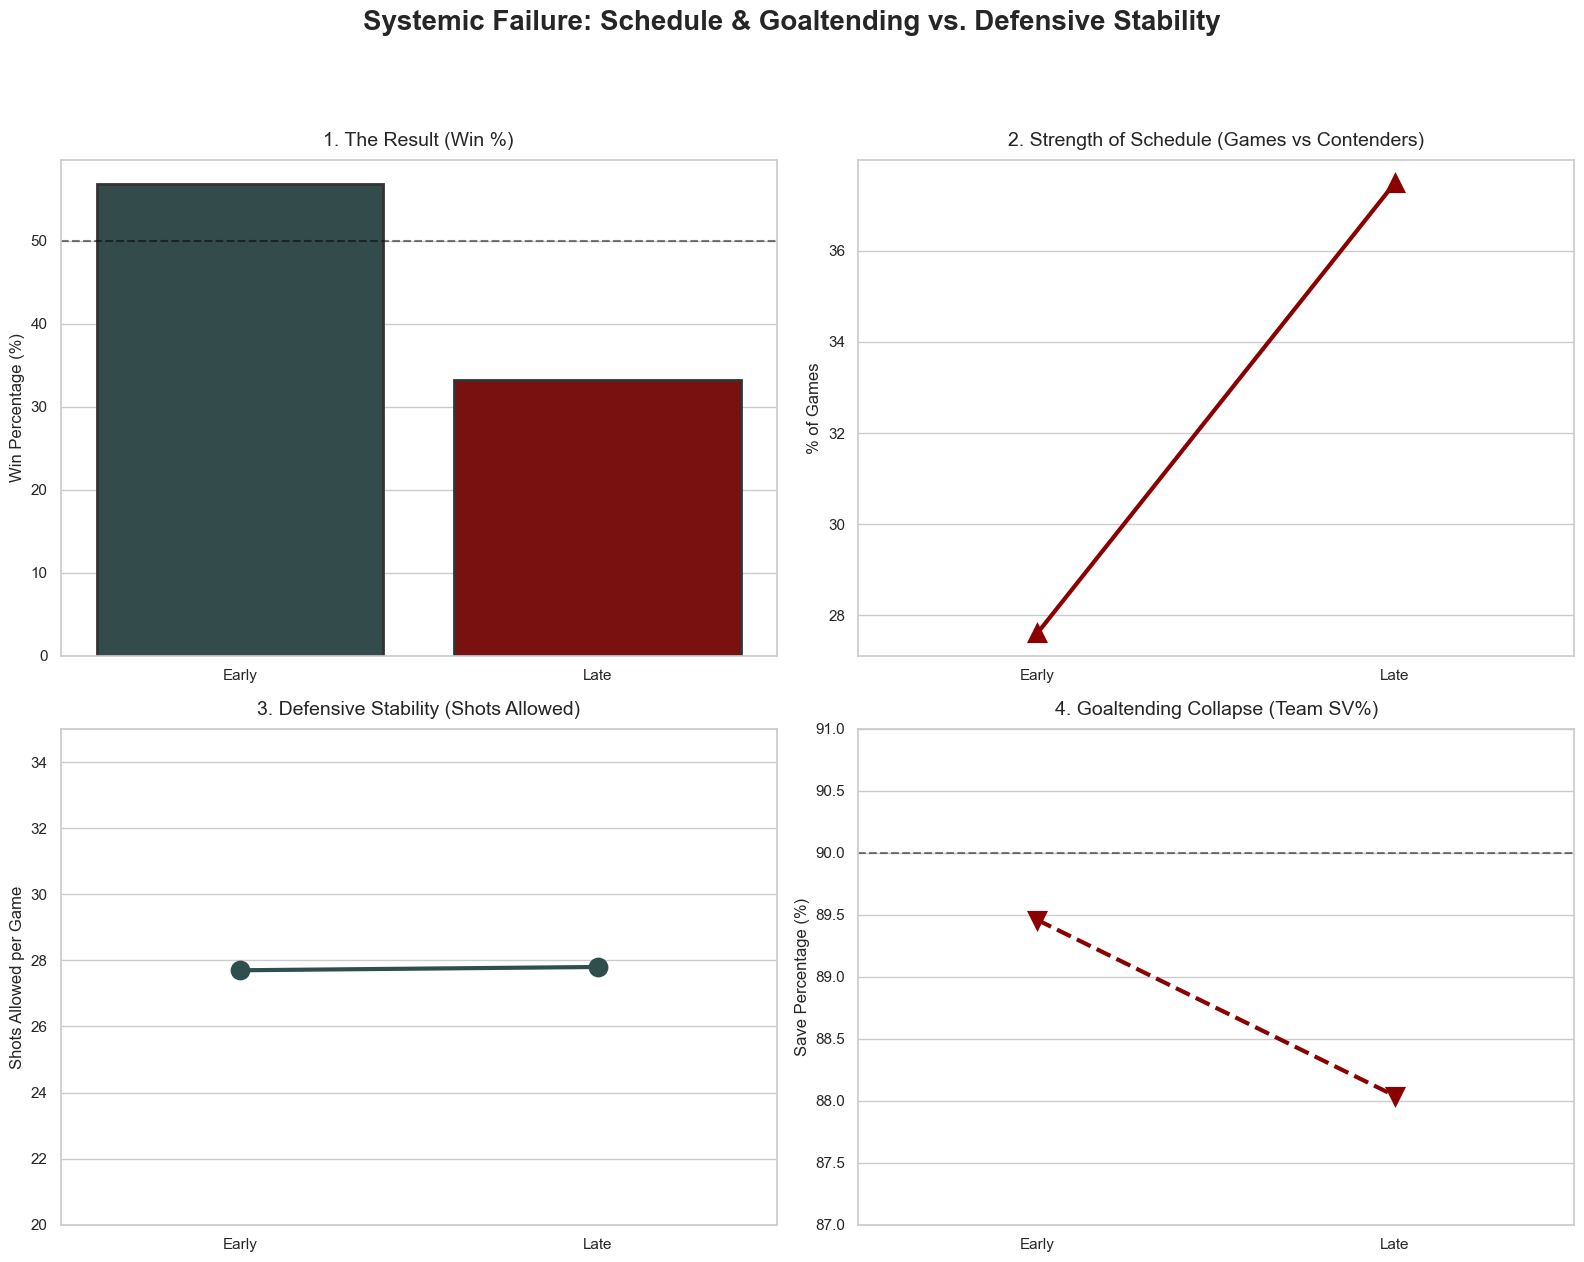

In [7]:
# ==========================================
# ANALYSIS #3: THE HOLISTIC BREAKDOWN
# CELL 2: THE 2x2 EXECUTIVE DASHBOARD
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a clean, professional aesthetic
sns.set_theme(style="whitegrid")

# Create a 2x2 grid for our four holistic metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Systemic Failure: Schedule & Goaltending vs. Defensive Stability', 
             fontsize=20, fontweight='bold', y=1.05)

# --- DATA PREP ---
# We need to strip the '%' strings and convert to floats for plotting
df_viz = system_summary.copy()
df_viz['win_percentage'] = df_viz['win_percentage'].str.rstrip('%').astype(float)
df_viz['pct_games_vs_contenders'] = df_viz['pct_games_vs_contenders'].str.rstrip('%').astype(float)
df_viz['team_save_pct'] = df_viz['team_save_pct'].str.rstrip('%').astype(float)

# Custom Color Palette
phase_colors = {"Early": "#2F4F4F", "Late": "#8B0000"}

# --- PANEL 1: The Result (Win % Drop) ---
sns.barplot(
    data=df_viz, x='season_phase', y='win_percentage', hue='season_phase',
    palette=phase_colors, ax=axes[0, 0], edgecolor=".2", linewidth=2, legend=False
)
axes[0, 0].set_title('1. The Result (Win %)', fontsize=14, pad=10)
axes[0, 0].set_ylabel('Win Percentage (%)', fontsize=12)
axes[0, 0].set_xlabel('')
# Add a 50% baseline reference
axes[0, 0].axhline(50, color='black', linestyle='--', alpha=0.5)

# --- PANEL 2: The Excuse (Quality of Competition) ---
sns.pointplot(
    data=df_viz, x='season_phase', y='pct_games_vs_contenders', 
    color="#8B0000", markers='^', linestyles='-', linewidth=3, markersize=12, ax=axes[0, 1]
)
axes[0, 1].set_title('2. Strength of Schedule (Games vs Contenders)', fontsize=14, pad=10)
axes[0, 1].set_ylabel('% of Games', fontsize=12)
axes[0, 1].set_xlabel('')

# --- PANEL 3: The Stable Variable (Defense) ---
sns.pointplot(
    data=df_viz, x='season_phase', y='avg_shots_allowed', 
    color="#2F4F4F", markers='o', linestyles='-', linewidth=3, markersize=12, ax=axes[1, 0]
)
axes[1, 0].set_title('3. Defensive Stability (Shots Allowed)', fontsize=14, pad=10)
axes[1, 0].set_ylabel('Shots Allowed per Game', fontsize=12)
axes[1, 0].set_xlabel('')
# Set y-axis limits to show that 27.7 to 27.8 is essentially a flatline
axes[1, 0].set_ylim(20, 35) 

# --- PANEL 4: The Fatal Blow (Goaltending) ---
sns.pointplot(
    data=df_viz, x='season_phase', y='team_save_pct', 
    color="#8B0000", markers='v', linestyles='--', linewidth=3, markersize=12, ax=axes[1, 1]
)
axes[1, 1].set_title('4. Goaltending Collapse (Team SV%)', fontsize=14, pad=10)
axes[1, 1].set_ylabel('Save Percentage (%)', fontsize=12)
axes[1, 1].set_xlabel('')
# Add the NHL average .900 (90%) as a reference line
axes[1, 1].axhline(90.0, color='black', linestyle='--', alpha=0.5)
# Set appropriate scale for Save % 
axes[1, 1].set_ylim(87, 91)

# Clean up layout and save
plt.tight_layout()
plt.savefig('systemic_failure_dashboard.png', bbox_inches='tight', dpi=300)
print("[Success] Quad-Dashboard visualization saved as 'systemic_failure_dashboard.png'")
plt.show()